## **Block 1: Setup and Data Loading**

In [ ]:
"""
RideConnect — Driver Behavior Anomaly Detector
Algorithm: Isolation Forest (unsupervised)
Features: speed, acceleration, heading change, route deviation, stop duration
Output: anomaly score per GPS ping; -1 = anomaly, +1 = normal
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Reproducibility
np.random.seed(42)

# If you already have ml_anomaly_features.csv from the earlier synthetic
# dataset generation, load it directly. Otherwise we'll generate it below.
try:
    df = pd.read_csv("/content/ml_anomaly_features.csv")
    print(f"Loaded existing dataset: {df.shape}")
except FileNotFoundError:
    print("Dataset not found, will generate synthetic GPS feature data...")
    df = None

print(df.head() if df is not None else "Run Block 2 to generate.")

Dataset not found, will generate synthetic GPS feature data...
Run Block 2 to generate.


## **Block 2: Generate Synthetic GPS Feature Data (if needed)**

In [ ]:
# Skip this block if Block 1 successfully loaded the CSV.

NUM_NORMAL = 4750         # 95% normal driving
NUM_ANOMALOUS = 250       # 5% injected anomalies (matches contamination rate)

# ---------- Generate NORMAL driving patterns ----------
# Kigali realistic ranges:
#   speed:        10-65 km/h (urban driving)
#   acceleration: -2.0 to +2.0 m/s² (gentle)
#   heading:      0-30 degree changes (smooth turns)
#   deviation:    0-50m off planned route (normal GPS noise)
#   stop time:    0-180s (traffic lights, brief stops)

normal = pd.DataFrame({
    "speed_kmh":              np.random.uniform(10, 65, NUM_NORMAL),
    "acceleration_ms2":       np.random.normal(0, 1.0, NUM_NORMAL).clip(-2.0, 2.0),
    "heading_change_degrees": np.abs(np.random.normal(5, 10, NUM_NORMAL)).clip(0, 30),
    "route_deviation_meters": np.abs(np.random.normal(15, 12, NUM_NORMAL)).clip(0, 50),
    "stop_duration_seconds":  np.abs(np.random.exponential(30, NUM_NORMAL)).clip(0, 180),
    "is_anomaly": 0,
})

# ---------- Inject ANOMALIES (deliberately extreme) ----------
# Real driver issues we want to catch:
#  1. Reckless driving:  speed > 90 km/h
#  2. Hard braking:      acceleration < -4 m/s²
#  3. Erratic turning:   heading change > 60° between pings
#  4. Route fraud:       deviation > 300m (passenger kidnapping / detour scam)
#  5. Suspicious stop:   stopped > 8 min mid-trip (not at a destination)

anomalies = []
for _ in range(NUM_ANOMALOUS):
    anomaly_type = np.random.choice(["speeding", "harsh_brake", "erratic", "route_fraud", "long_stop"])
    if anomaly_type == "speeding":
        row = {"speed_kmh": np.random.uniform(90, 160), "acceleration_ms2": 4.0,
               "heading_change_degrees": 5, "route_deviation_meters": 20, "stop_duration_seconds": 0}
    elif anomaly_type == "harsh_brake":
        row = {"speed_kmh": np.random.uniform(40, 80), "acceleration_ms2": np.random.uniform(-9, -4),
               "heading_change_degrees": 10, "route_deviation_meters": 15, "stop_duration_seconds": 0}
    elif anomaly_type == "erratic":
        row = {"speed_kmh": np.random.uniform(25, 50), "acceleration_ms2": np.random.uniform(-3, 3),
               "heading_change_degrees": np.random.uniform(60, 180),
               "route_deviation_meters": 25, "stop_duration_seconds": 0}
    elif anomaly_type == "route_fraud":
        row = {"speed_kmh": np.random.uniform(20, 60), "acceleration_ms2": 0.5,
               "heading_change_degrees": 15,
               "route_deviation_meters": np.random.uniform(300, 900),
               "stop_duration_seconds": 0}
    else:  # long_stop
        row = {"speed_kmh": 0, "acceleration_ms2": 0,
               "heading_change_degrees": 0, "route_deviation_meters": 20,
               "stop_duration_seconds": np.random.uniform(480, 1800)}
    row["is_anomaly"] = 1
    anomalies.append(row)

anomalies = pd.DataFrame(anomalies)
df = pd.concat([normal, anomalies], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated dataset: {df.shape}")
print(f"Normal: {(df.is_anomaly==0).sum()}, Anomalies: {(df.is_anomaly==1).sum()}")
df.head()

Generated dataset: (5000, 6)
Normal: 4750, Anomalies: 250


,speed_kmh,acceleration_ms2,heading_change_degrees,route_deviation_meters,stop_duration_seconds,is_anomaly
0,36.355003,-1.133830,2.710422,22.527937,112.230536,0
1,13.947669,-0.925890,9.910039,15.612916,63.650982,0
2,12.879526,0.306451,3.306711,12.560421,28.583160,0
3,29.289150,-0.419435,1.642214,15.151854,8.217510,0
4,64.447813,0.662052,13.865795,15.477593,31.164801,0


## **Block 3: Train the Isolation Forest**

In [ ]:
FEATURE_COLS = [
    "speed_kmh", "acceleration_ms2", "heading_change_degrees",
    "route_deviation_meters", "stop_duration_seconds",
]

# Critical: train on NORMAL data only — unsupervised learns "what normal looks like"
X_normal = df[df.is_anomaly == 0][FEATURE_COLS].copy()
print(f"Training on {len(X_normal)} normal samples")

# Scale features so all dimensions contribute equally
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)

# Train the model
detector = IsolationForest(
    n_estimators=100,        # 100 trees — robust without being slow
    contamination=0.05,      # we expect ~5% of live data to be anomalous
    max_features=1.0,        # use all features in each tree split
    random_state=42,
    n_jobs=-1,
)
detector.fit(X_normal_scaled)
print("Model trained.")

Training on 4750 normal samples
Model trained.


## **Block 4: Evaluate on the Full Dataset**

ISOLATION FOREST PERFORMANCE
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96      4750
     Anomaly       0.30      0.42      0.35       250

    accuracy                           0.92      5000
   macro avg       0.64      0.68      0.66      5000
weighted avg       0.94      0.92      0.93      5000

Precision: 0.304
Recall:    0.416
F1:        0.351


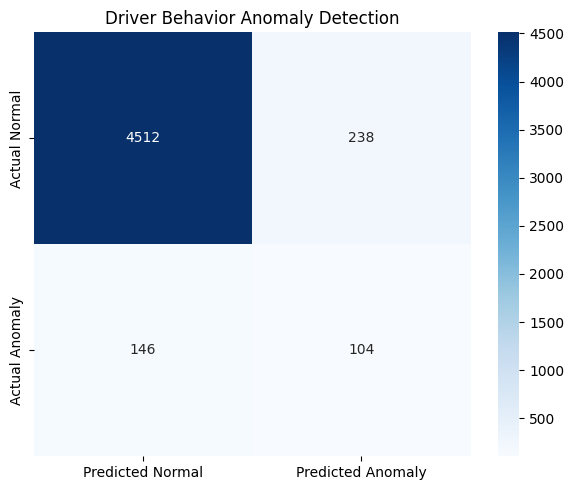

In [ ]:
# Now evaluate on the FULL dataset (normal + injected anomalies)
X_all = df[FEATURE_COLS].copy()
X_all_scaled = scaler.transform(X_all)

# predict() returns +1 for normal, -1 for anomaly
predictions = detector.predict(X_all_scaled)

# Convert to 0/1 for sklearn metrics (0=normal, 1=anomaly)
pred_anomaly = (predictions == -1).astype(int)
true_anomaly = df.is_anomaly.values

# Also get the raw scores — lower = more anomalous
scores = detector.score_samples(X_all_scaled)
df["anomaly_score"] = scores
df["predicted_anomaly"] = pred_anomaly

# Print metrics
print("="*60)
print("ISOLATION FOREST PERFORMANCE")
print("="*60)
print(classification_report(true_anomaly, pred_anomaly, target_names=["Normal", "Anomaly"]))
print(f"Precision: {precision_score(true_anomaly, pred_anomaly):.3f}")
print(f"Recall:    {recall_score(true_anomaly, pred_anomaly):.3f}")
print(f"F1:        {f1_score(true_anomaly, pred_anomaly):.3f}")

# Confusion matrix visualization
cm = confusion_matrix(true_anomaly, pred_anomaly)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted Anomaly"],
            yticklabels=["Actual Normal", "Actual Anomaly"])
plt.title("Driver Behavior Anomaly Detection")
plt.tight_layout()
plt.show()

## **Block 5: Save Artifacts for the Service**

In [ ]:
import json

# Save the trained detector + scaler — these are what your FastAPI service loads
joblib.dump(detector, "behavior_detector.pkl")
joblib.dump(scaler,   "behavior_scaler.pkl")

# Save feature config so the service knows what columns to expect, in what order
feature_config = {
    "feature_columns": FEATURE_COLS,
    "n_features": len(FEATURE_COLS),
    "model_type": "IsolationForest",
    "contamination": 0.05,
    "n_estimators": 100,
    "trained_on_samples": len(X_normal),
}
with open("behavior_feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

# Verify everything saved
import os
for fname in ["behavior_detector.pkl", "behavior_scaler.pkl", "behavior_feature_config.json"]:
    size = os.path.getsize(fname)
    print(f"  ✓ {fname}: {size:,} bytes")

# Bundle for download
import shutil
shutil.make_archive("/content/behavior_artifacts", "zip", "/content",
                    base_dir=None)
# Or selective:
import zipfile
with zipfile.ZipFile("/content/behavior_artifacts.zip", "w") as zf:
    for fname in ["behavior_detector.pkl", "behavior_scaler.pkl", "behavior_feature_config.json"]:
        zf.write(fname)

print("\n✅ Artifacts ready. Download behavior_artifacts.zip and copy to ml-service/models/trained/")

# Auto-download in Colab
from google.colab import files
files.download("/content/behavior_artifacts.zip")

NameError: name 'joblib' is not defined

In [ ]:
# In the Colab where you trained the model, run this verification cell:
test_cases = [
    ("reckless_160", [160.0, 5.0, 5.0, 10.0, 0.0]),
    ("normal_slow",  [25.0, 0.1, 5.0, 8.0, 12.0]),
    ("route_fraud",  [35.0, 0.2, 12.0, 850.0, 0.0]),
    ("long_stop",    [0.0, 0.0, 0.0, 20.0, 900.0]),
]
import numpy as np
for name, feats in test_cases:
    x = np.array([feats])
    x_scaled = scaler.transform(x)
    pred = detector.predict(x_scaled)[0]
    score = detector.score_samples(x_scaled)[0]
    print(f"{name:15s} → predict={pred:+d}, score={score:+.4f}, anomaly={pred==-1}")